# Custom CNN Model with PyTorch

这个 notebook 基于 `custom-cnn-model.ipynb` 的自定义 CNN 结构，并参考 `mnist-raw-data.ipynb` 手动准备 MNIST 原始 IDX 数据。**请按顺序从上到下运行**：先配置与 `raw_path` → **数据格会自动下载（若本地无文件）、解压、划分 train/valid/test** → 再定义模型并训练，最后保存检查点并查看曲线。

不使用 fastai，仅用 `torch` / 标准库完成下载、解析与训练。

In [32]:
from pathlib import Path
import gzip
import random
import struct
import urllib.request
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.utils import make_grid

In [33]:
seed = 2
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


def resolve_mnist_raw_path() -> Path:
    """在「无数据需下载」时也能落到可写目录；若某处已有 MNIST 文件则优先复用。"""
    cwd = Path.cwd().resolve()
    markers = ('train-images-idx3-ubyte', 'train-images-idx3-ubyte.gz')
    for rel in (Path('../../data/mnist-raw'), Path('../data/mnist-raw'), Path('data/mnist-raw')):
        cand = (cwd / rel).resolve()
        if any((cand / m).is_file() for m in markers):
            return cand
    if cwd.name == 'study-room':
        return (cwd / '../../data/mnist-raw').resolve()
    if (cwd / 'study-room').is_dir():
        return (cwd / 'data/mnist-raw').resolve()
    return (cwd / 'data/mnist-raw').resolve()


raw_path = resolve_mnist_raw_path()
batch_size = 16
epochs = 16
max_lr = 1e-2
num_workers = 0
valid_percent = 0.1

print(f'mnist raw_path -> {raw_path}')

# MPS 上部分卷积训练场景可能比 CPU 更容易遇到兼容性问题；如有报错可临时改成 torch.device('cpu')。
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

mnist raw_path -> /Users/donglu/Documents/development/repositories/data/mnist-raw


device(type='mps')

## 数据集：下载与划分

**自上而下**：先运行上一格得到 `raw_path`（会自动解析常见工作目录）；本格运行时会 **下载（若需要）→ 解压 → 读入 → 划分**。

下载写在 **`ensure_mnist_idx_files`** 里（内部 **`urllib.request.urlretrieve`**）：

- 已有解压后的 `*-ubyte` → **跳过**，不下载。
- 仅有 `*.gz` → **只解压**，不重复下载。
- 都没有 → 从 `MNIST_BASE` **下载** gzip 再解压。

划分：官方 `train`（60k）拆成 **训练 / 验证**（比例见 `valid_percent`）；官方 **`t10k` 固定为测试集**。

再往下是模型定义与训练单元。

In [34]:
# 数据集下载/解压：ensure_mnist_idx_files → urllib.request.urlretrieve（无本地文件时触发网络下载）
# 与 mnist-raw-data.ipynb 相同：MNIST 官方 IDX；已存在 ubyte 或仅 gzip 时不重复下载
MNIST_BASE = 'https://ossci-datasets.s3.amazonaws.com/mnist/'
MNIST_ARCHIVES = [
    ('train-images-idx3-ubyte.gz', 'train-images-idx3-ubyte'),
    ('train-labels-idx1-ubyte.gz', 'train-labels-idx1-ubyte'),
    ('t10k-images-idx3-ubyte.gz', 't10k-images-idx3-ubyte'),
    ('t10k-labels-idx1-ubyte.gz', 't10k-labels-idx1-ubyte'),
]


def ensure_mnist_idx_files(root: Path) -> None:
    root = Path(root)
    root.mkdir(parents=True, exist_ok=True)
    for gz_name, ubyte_name in MNIST_ARCHIVES:
        gz_path = root / gz_name
        ubyte_path = root / ubyte_name
        if ubyte_path.is_file():
            print(f'skip (exists): {ubyte_path.name}')
            continue
        if not gz_path.is_file():
            url = MNIST_BASE + gz_name
            print(f'download: {gz_name} <- {url}')
            try:
                urllib.request.urlretrieve(url, gz_path)
            except Exception as e:
                raise RuntimeError(
                    f'下载失败（请检查网络/代理）: {url}\n'
                    f'也可手动将 {gz_name} 放到目录: {root}'
                ) from e
        else:
            print(f'using local gzip: {gz_name}')
        print(f'extract -> {ubyte_name}')
        with gzip.open(gz_path, 'rb') as f_in:
            ubyte_path.write_bytes(f_in.read())
    for _, ubyte_name in MNIST_ARCHIVES:
        ubyte_path = root / ubyte_name
        if not ubyte_path.is_file() or ubyte_path.stat().st_size < 16:
            raise RuntimeError(f'MNIST 文件缺失或损坏: {ubyte_path}')


def load_mnist_images(ubyte_path: Path) -> np.ndarray:
    with open(ubyte_path, 'rb') as f:
        data = f.read()
    _magic, n, rows, cols = struct.unpack_from('>IIII', data, 0)
    offset = 16
    fmt_image = '>' + str(rows * cols) + 'B'
    images = np.empty((n, rows, cols), dtype=np.float32)
    for i in range(n):
        images[i] = np.array(struct.unpack_from(fmt_image, data, offset), dtype=np.float32).reshape(rows, cols)
        offset += struct.calcsize(fmt_image)
    return images / 255.0


def load_mnist_labels(ubyte_path: Path) -> np.ndarray:
    with open(ubyte_path, 'rb') as f:
        data = f.read()
    _magic, n = struct.unpack_from('>II', data, 0)
    return np.frombuffer(data, dtype=np.uint8, offset=8).copy().astype(np.int64)


class MnistTensorDataset(Dataset):
    """单通道 float32，与 mnist-raw-data 中 ToTensor 后数值一致，再按 MNIST 均值方差归一化。"""

    def __init__(self, images: np.ndarray, labels: np.ndarray, mean: float = 0.1307, std: float = 0.3081):
        if len(images) != len(labels):
            raise ValueError('images and labels length mismatch')
        self.images = torch.from_numpy(images).unsqueeze(1)
        self.labels = torch.as_tensor(labels, dtype=torch.long)
        self.mean = mean
        self.std = std

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        x = (self.images[idx] - self.mean) / self.std
        return x, self.labels[idx]


ensure_mnist_idx_files(raw_path)

train_images = load_mnist_images(raw_path / 'train-images-idx3-ubyte')
train_labels = load_mnist_labels(raw_path / 'train-labels-idx1-ubyte')
test_images = load_mnist_images(raw_path / 't10k-images-idx3-ubyte')
test_labels = load_mnist_labels(raw_path / 't10k-labels-idx1-ubyte')

assert len(train_images) == 60_000 and len(train_labels) == 60_000
assert len(test_images) == 10_000 and len(test_labels) == 10_000

full_train_ds = MnistTensorDataset(train_images, train_labels)
test_ds = MnistTensorDataset(test_images, test_labels)

_gen = torch.Generator().manual_seed(seed)
n_train_total = len(full_train_ds)
n_valid = max(1, int(round(n_train_total * valid_percent)))
n_train = n_train_total - n_valid
assert n_train >= 1
train_ds, valid_ds = random_split(full_train_ds, [n_train, n_valid], generator=_gen)

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valid_dl = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

classes = [str(i) for i in range(10)]
(
    f'train={len(train_ds)} valid={len(valid_ds)} test={len(test_ds)}',
    classes,
    str(raw_path.resolve()),
)

skip (exists): train-images-idx3-ubyte
skip (exists): train-labels-idx1-ubyte
skip (exists): t10k-images-idx3-ubyte
skip (exists): t10k-labels-idx1-ubyte


('train=54000 valid=6000 test=10000',
 ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
 '/Users/donglu/Documents/development/repositories/data/mnist-raw')

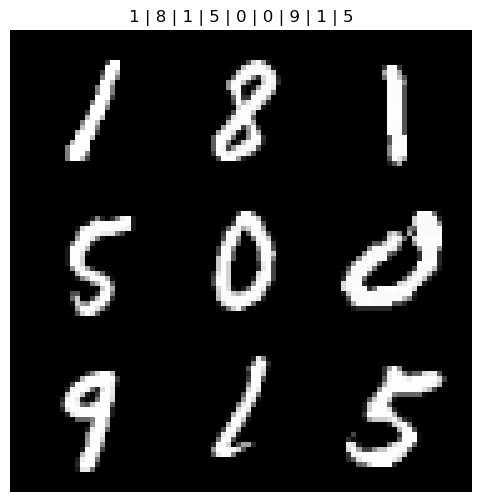

In [35]:
def show_batch(dl, n=9, mean=0.1307, std=0.3081):
    images, labels = next(iter(dl))
    images = images[:n]
    labels = labels[:n]
    vis = (images * std + mean).clamp(0, 1)
    grid = make_grid(vis.repeat(1, 3, 1, 1), nrow=3)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title(' | '.join(str(i.item()) for i in labels))
    plt.show()

show_batch(train_dl)

In [36]:
class MyBlockModel(nn.Module):
    def __init__(self, num_classes=10, init_weights=True, batch_norm=True):
        super().__init__()
        cfgs = [16, 16, 'M', 32, 32, 'M', 32, 32, 'M']
        layers = []
        in_channels = 1

        for v in cfgs:
            if v == 'M':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
                continue

            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v

        self.features = nn.Sequential(*layers)
        # 使用 (1,1) 全局平均池化，避免 AdaptiveAvgPool 在非整除尺寸下触发 MPS 限制
        # （28x28 经 3 次 MaxPool 后为 3x3，若目标为 (7,7) 会在 MPS 上报错）
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(32, 256),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(256, 256),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(256, num_classes),
        )

        if init_weights:
            self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

In [37]:
model = MyBlockModel(num_classes=10, batch_norm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=max_lr,
    epochs=epochs,
    steps_per_epoch=len(train_dl),
)

model

MyBlockModel(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(32, 

In [38]:
def run_epoch(model, dl, criterion, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in dl:
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(is_train):
            preds = model(xb)
            loss = criterion(preds, yb)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

        batch_size_now = xb.size(0)
        total_loss += loss.item() * batch_size_now
        total_correct += (preds.argmax(dim=1) == yb).sum().item()
        total_count += batch_size_now

    avg_loss = total_loss / total_count
    accuracy = total_correct / total_count
    return avg_loss, accuracy

In [39]:
history = {
    'train_loss': [],
    'valid_loss': [],
    'train_acc': [],
    'valid_acc': [],
    'lr': [],
}

for epoch in range(epochs):
    train_loss, train_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler)
    valid_loss, valid_acc = run_epoch(model, valid_dl, criterion)

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['train_acc'].append(train_acc)
    history['valid_acc'].append(valid_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"train_loss={train_loss:.4f} valid_loss={valid_loss:.4f} "
        f"train_acc={train_acc:.4f} valid_acc={valid_acc:.4f}"
    )

test_loss, test_acc = run_epoch(model, test_dl, criterion)
print(f'Test loss={test_loss:.4f} acc={test_acc:.4f}')

Epoch 01/16 train_loss=0.9027 valid_loss=0.1772 train_acc=0.6458 valid_acc=0.9493
Epoch 02/16 train_loss=0.1657 valid_loss=0.3650 train_acc=0.9536 valid_acc=0.8963
Epoch 03/16 train_loss=0.1517 valid_loss=0.1032 train_acc=0.9620 valid_acc=0.9768
Epoch 04/16 train_loss=0.1791 valid_loss=0.1648 train_acc=0.9590 valid_acc=0.9627
Epoch 05/16 train_loss=0.1832 valid_loss=0.1225 train_acc=0.9604 valid_acc=0.9737
Epoch 06/16 train_loss=0.1747 valid_loss=0.4096 train_acc=0.9630 valid_acc=0.9392
Epoch 07/16 train_loss=0.1618 valid_loss=0.1688 train_acc=0.9650 valid_acc=0.9597
Epoch 08/16 train_loss=0.1477 valid_loss=0.0891 train_acc=0.9702 valid_acc=0.9798
Epoch 09/16 train_loss=0.1177 valid_loss=0.0879 train_acc=0.9749 valid_acc=0.9825
Epoch 10/16 train_loss=0.0964 valid_loss=0.0852 train_acc=0.9802 valid_acc=0.9822
Epoch 11/16 train_loss=0.0747 valid_loss=0.0439 train_acc=0.9836 valid_acc=0.9888
Epoch 12/16 train_loss=0.0586 valid_loss=0.0560 train_acc=0.9870 valid_acc=0.9872
Epoch 13/16 trai

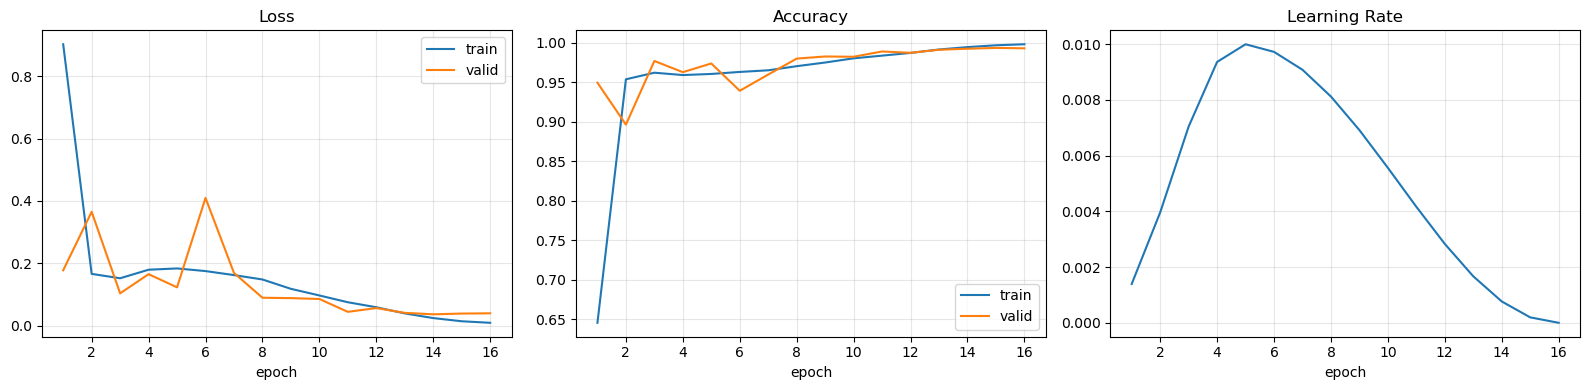

In [40]:
epoch_axis = np.arange(1, epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epoch_axis, history['train_loss'], label='train')
axes[0].plot(epoch_axis, history['valid_loss'], label='valid')
axes[0].set_title('Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_axis, history['train_acc'], label='train')
axes[1].plot(epoch_axis, history['valid_acc'], label='valid')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epoch_axis, history['lr'])
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('epoch')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
models_dir = raw_path / 'models'
models_dir.mkdir(exist_ok=True)

checkpoint_path = models_dir / 'custom-model-torch.pth'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'classes': classes,
        'history': history,
    },
    checkpoint_path,
)

checkpoint_path

PosixPath('/Users/donglu/Documents/development/repositories/data/mnist-raw/models/custom-model-torch.pth')

In [42]:
# ONNX：单文件内含计算图与权重；JSON 记录输入尺寸、类别与归一化说明（供 C++/ONNX Runtime 等非 PyTorch 端使用）
model.eval()

onnx_path = models_dir / 'custom-model-torch.onnx'
meta_path = models_dir / 'custom-model-torch-onnx.json'

_export = MyBlockModel(num_classes=len(classes), batch_norm=True).cpu()
_export.load_state_dict(model.state_dict())
dummy = torch.randn(1, 1, 28, 28)

# PyTorch 新版本默认 dynamo=True，会依赖 onnxscript；此处用 legacy 导出避免额外安装
torch.onnx.export(
    _export,
    dummy,
    str(onnx_path),
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    dynamo=False,
    input_names=['input'],
    output_names=['logits'],
    dynamic_axes={'input': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
)

meta = {
    'model_class': 'MyBlockModel',
    'input': {'name': 'input', 'shape_static_example': [1, 1, 28, 28], 'dynamic_batch': True},
    'output': {'name': 'logits', 'shape_static_example': [1, len(classes)]},
    'num_classes': len(classes),
    'classes': classes,
    'opset_version': 17,
    'preprocess': {'grayscale': True, 'normalize_mean': 0.1307, 'normalize_std': 0.3081, 'same_as_notebook': 'MnistTensorDataset'},
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')

model.to(device)
onnx_path, meta_path


/var/folders/1b/p033jzds09l3ngy6vznlggx40000gn/T/ipykernel_34357/2017511965.py:12: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


(PosixPath('/Users/donglu/Documents/development/repositories/data/mnist-raw/models/custom-model-torch.onnx'),
 PosixPath('/Users/donglu/Documents/development/repositories/data/mnist-raw/models/custom-model-torch-onnx.json'))